mu = 0.7 low Tc
dopping_x = 1.2470025012589758e-12 Tc = 0.0
 Delta: [0.]
mu = 0.6781879194630872 low Tc
dopping_x = 1.2230216839270724e-12 Tc = 0.0
 Delta: [0.]
mu = 0.6563758389261745 low Tc
dopping_x = 1.2567724638756772e-12 Tc = 0.0
 Delta: [0.]
mu = 0.6345637583892617 low Tc
dopping_x = 1.2532197501968767e-12 Tc = 0.0
 Delta: [0.]
mu = 0.612751677852349 low Tc
dopping_x = 1.247668635073751e-12 Tc = 0.0
 Delta: [0.]
mu = 0.5909395973154362 low Tc
dopping_x = 1.2319034681240737e-12 Tc = 0.0
 Delta: [0.]
mu = 0.5691275167785235 low Tc
dopping_x = 1.2447820552097255e-12 Tc = 0.0
 Delta: [0.]
mu = 0.5473154362416107 low Tc
dopping_x = 1.2738698984549046e-12 Tc = 0.0
 Delta: [0.]
mu = 0.525503355704698 low Tc
dopping_x = 1.2648770919554408e-12 Tc = 0.0
 Delta: [0.]
mu = 0.5036912751677852 low Tc
dopping_x = 1.244448988302338e-12 Tc = 0.0
 Delta: [0.]
mu = 0.4818791946308725 low Tc
dopping_x = 1.238231739364437e-12 Tc = 0.0
 Delta: [0.]
mu = 0.46006711409395973 low Tc
dopping_x = 1.272981

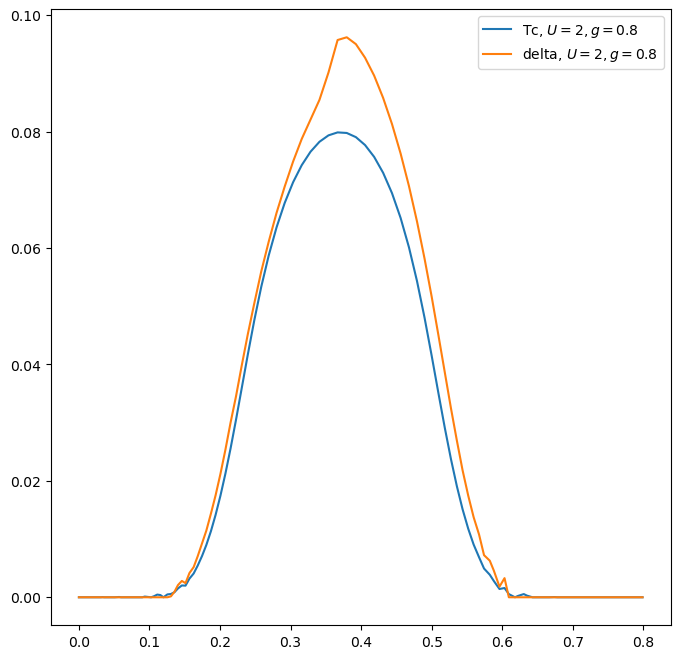

In [1]:
#Fermi arc model mean-field zero-temperature gap
#U = 0 corresponds to BCS gap equation
#U > 0 corresponds to Fermi arc model mean-field gap equation
#mean-field gap equation: (J / N) \sum_{\mathbf{k}} \int d \omega A(\mathbf{k}, \omega) g_{\mathbf{k}}^2 /\left(2 \sqrt{\omega^2+\Delta^2(0) g_{\mathbf{k}}^2}\right)=1
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq
from scipy.optimize import root
import time

kB = 1.0
t = 1.0
t1 = -0.2
t2 = 0.1
g = 0.8

Q = [np.pi, np.pi]

U = 2

Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

k_points = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
kx, ky = np.meshgrid(k_points, k_points)
Total_K_Points = Nk**2

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    gamma = np.cos(KX) - np.cos(KY)
    #gamma = 1
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = gamma*gamma*(1.0 - n_k)*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)*beta/4.0,
                     term_1_numerator/term_1_denominator)
    
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = gamma*gamma*n_k*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k*beta/4.0,
                     term_2_numerator/term_2_denominator)

    term_3_denominator = 2.0*epsilon_minus_mu + U
    term_3_numerator = gamma*gamma*n_k*(1-n_k)*U*(np.tanh(beta*epsilon_plus_U/2.0)/2/epsilon_plus_U - np.tanh(beta*epsilon_minus_mu/2.0)/2/epsilon_minus_mu)
    term_3 = term_3_numerator/term_3_denominator
    term_3 = 0
    
    chi0 = np.sum(term_1 + term_2 + term_3)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

mu_list = np.linspace(0.70, -2.55, 150)  #U=2.0
#mu_list = np.linspace(0.5, -2.75, 150)  #U=1.7
#mu_list = np.linspace(0.1, -3.15, 150)  #U=1.4
#mu_list = np.linspace(-0.15, -3.4, 150)  #U=1.1

Tc_results = []
Doping_x_results = []
delta_results = []

start_time = time.time()

def mean_field_gap_equation(Delta):
    #if Delta < 1e-8:
    #    Delta = 1e-8 
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    g_k = np.cos(KX) - np.cos(KY)
    T = 0
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)

    epsilon_minus_mu = epsilon - mu
    
    E_k = np.sqrt(epsilon_minus_mu*epsilon_minus_mu + Delta*Delta*g_k*g_k + 1e-6)
    E_k_U = np.sqrt((epsilon_minus_mu+U)*(epsilon_minus_mu+U) + Delta*Delta*g_k*g_k + 1e-6)
    
    f_k = (g_k*g_k*(1-n_k)) / (2 * E_k) + (g_k*g_k*n_k) / (2 * E_k_U)
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
Tc_results = []
Doping_x_results = []
delta_results = []
for mu in mu_list:
    Tc = find_Tc(mu, U, g)
    T_threshold = 1e-6
    if Tc > T_threshold:
        avg_n = average_occupation(mu, Tc, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    else:
        avg_n = average_occupation(mu, T_threshold, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    print('dopping_x =', doping_x, 'Tc =', Tc)
    Tc_results.append(Tc)
    Doping_x_results.append(doping_x)

    sol = root(
        mean_field_gap_equation, 
        Tc, 
        method='lm',
        tol=1e-6,
    )
    if sol.success:
        delta = sol.x
        print(f" Delta: {delta}")
    else:
        print("error", sol.message)
    delta_results.append(delta)


x_plot = np.array(Doping_x_results)
Tc_plot = np.array(Tc_results)
delta_plot = np.array(delta_results)

mask_lower = x_plot >= 0
mask_upper = x_plot < 0.8
mask_combined = mask_lower & mask_upper

Tc_final = Tc_plot[mask_combined]
x_final = x_plot[mask_combined]
delta_final = delta_plot[mask_combined]

sort_indices = np.argsort(x_final)
x_final = x_final[sort_indices]
Tc_final = Tc_final[sort_indices]

end_time = time.time()
print(end_time-start_time)

#np.save(f'Tc_U{U:g}_g{g:g}_N{Nk:g}_mean', Tc_final)
#np.save(f'x_U{U:g}_g{g:g}_N{Nk:g}_mean', x_final)
#np.save(f'delta_U{U:g}_g{g:g}_N{Nk:g}_mean', delta_final)

plt.figure(figsize=(8, 8))
#plt.plot(x_final, Tc_final, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
#plt.plot(x_final_0, Tc_final_0, 'co-', linewidth=2, markersize=4, label=f'$U={U}, g={g}, non-interacting$')
plt.plot(x_final, Tc_final, label=f'Tc, $U={U}, g={g}$')
plt.plot(x_final, delta_final, label=f'delta, $U={U}, g={g}$')
plt.legend()
plt.show() 

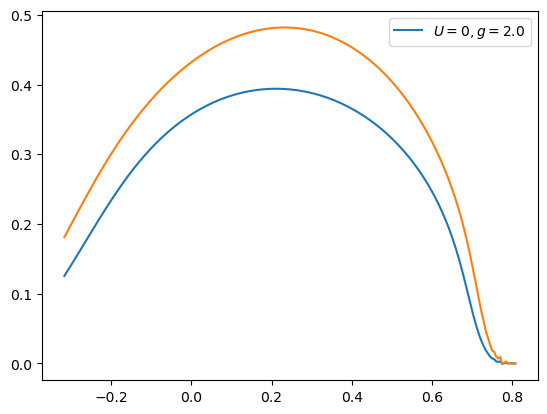

In [39]:
#Tc_results = []
#Doping_x_results = []
#delta_results = []
plt.plot(Doping_x_results, Tc_results, label=f'$U={U}, g={g}$')
plt.plot(Doping_x_results, delta_results)
plt.legend()

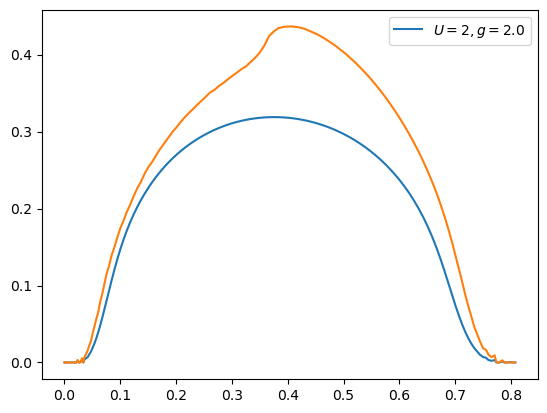

In [41]:
#Tc_results = []
#Doping_x_results = []
#delta_results = []
plt.plot(Doping_x_results, Tc_results, label=f'$U={U}, g={g}$')
plt.plot(Doping_x_results, delta_results)
plt.legend()